In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile, os

with zipfile.ZipFile('archive (1).zip', 'r') as z:
    z.extractall('/content/flowers')

print(os.listdir('/content/flowers'))

['flowers']


In [ ]:
print(os.listdir('/content/flowers/flowers'))

['rose', 'tulip', 'daisy', 'sunflower', 'dandelion']


In [ ]:
import os
import matplotlib.pyplot as plt

dataset_path = '/content/flowers/flowers'

for folder in os.listdir(dataset_path):
    path = f"{dataset_path}/{folder}"
    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f"{folder}: {count} images")

rose: 784 images
tulip: 984 images
daisy: 764 images
sunflower: 733 images
dandelion: 1052 images


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                      Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


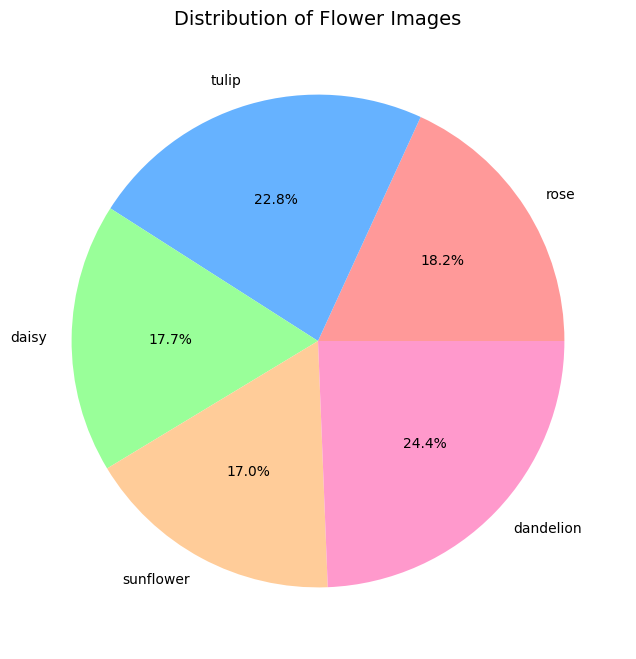

In [ ]:
counts = {}
for folder in os.listdir(dataset_path):
    path = f"{dataset_path}/{folder}"
    if os.path.isdir(path):
        counts[folder] = len(os.listdir(path))

plt.figure(figsize=(8, 8))
plt.pie(counts.values(),
        labels=counts.keys(),
        autopct='%1.1f%%',
        colors=['#FF9999','#66B2FF','#99FF99','#FFCC99','#FF99CC'])
plt.title('Distribution of Flower Images', fontsize=14)
plt.show()

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

# Remove rescale! EfficientNetB3 handles it internally
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Classes: {train_gen.class_indices}")


Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
Training samples: 3457
Validation samples: 860
Classes: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


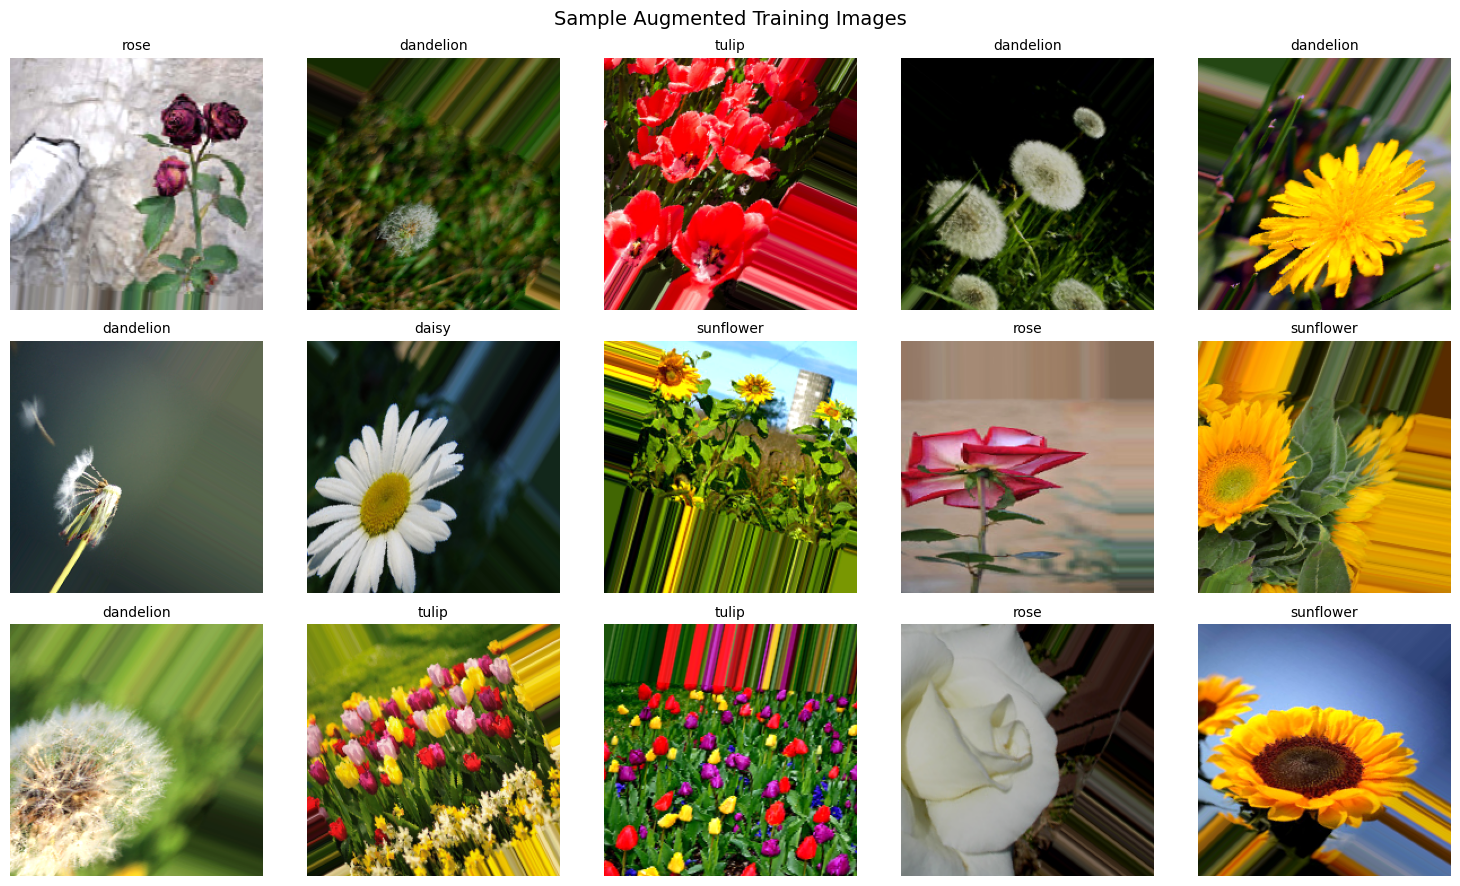

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
class_names = list(train_gen.class_indices.keys())

for i, ax in enumerate(axes.flat):
    img, label = next(train_gen)
    # Clip pixel values to 0-255 range for display
    display_img = img[0].astype('uint8')
    ax.imshow(display_img)
    ax.set_title(class_names[np.argmax(label[0])], fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Augmented Training Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def build_efficientnetb3(n_classes=5):
    base_model = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    output = Dense(n_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

model, base_model = build_efficientnetb3()

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

for layer in model.layers:
    layer.trainable = True

for layer in model.layers[:-60]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7)
    ]
)

model.save('efficientnetb3_flowers.h5')
print("Model Saved!")

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 119s 398ms/step - accuracy: 0.8901 - loss: 0.3044 - val_accuracy: 0.9140 - val_loss: 0.2508
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 55s 252ms/step - accuracy: 0.8866 - loss: 0.3069 - val_accuracy: 0.9140 - val_loss: 0.2493
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 57s 264ms/step - accuracy: 0.8886 - loss: 0.2912 - val_accuracy: 0.9151 - val_loss: 0.2498
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 54s 251ms/step - accuracy: 0.8947 - loss: 0.2923 - val_accuracy: 0.9209 - val_loss: 0.2431
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 55s 254ms/step - accuracy: 0.8944 - loss: 0.2952 - val_accuracy: 0.9058 - val_loss: 0.2594
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 56s 259ms/step - accuracy: 0.8933 - loss: 0.2947 - val_accuracy: 0.9186 - val_loss: 0.2484
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 55s 256ms/step - accuracy: 0.8869 - loss: 0.3022 - val_accuracy: 0.9186 - val_loss: 0.2485
Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 141s 442ms/step - accuracy: 0.8452 - loss:

Model Saved!


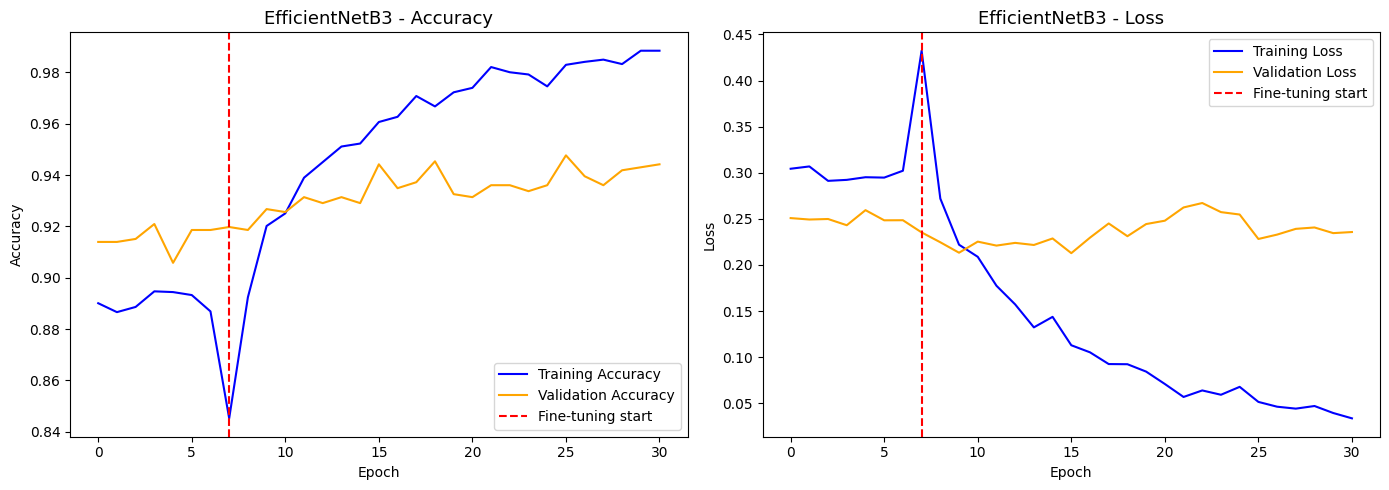

In [ ]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Training Accuracy', color='blue')
ax1.plot(val_acc, label='Validation Accuracy', color='orange')
ax1.axvline(x=len(history1.history['accuracy']),
            color='red', linestyle='--', label='Fine-tuning start')
ax1.set_title('EfficientNetB3 - Accuracy', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(loss, label='Training Loss', color='blue')
ax2.plot(val_loss, label='Validation Loss', color='orange')
ax2.axvline(x=len(history1.history['loss']),
            color='red', linestyle='--', label='Fine-tuning start')
ax2.set_title('EfficientNetB3 - Loss', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 225ms/step


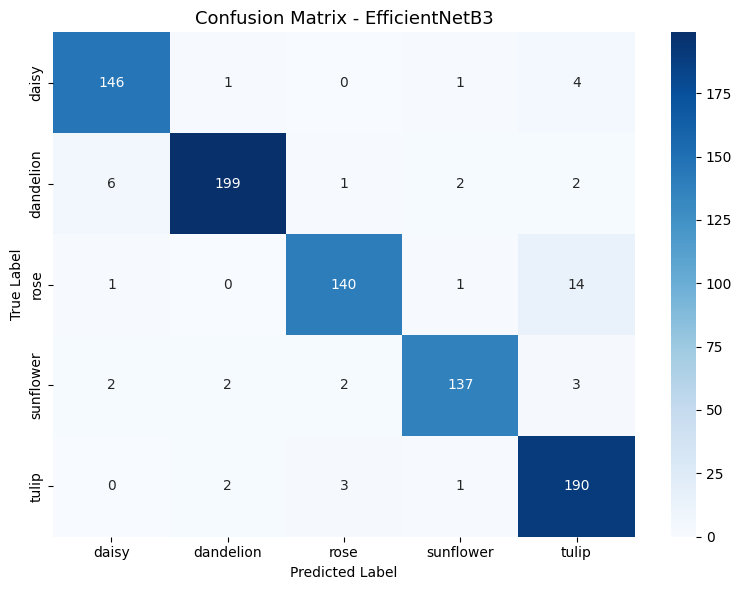


Classification Report:
              precision    recall  f1-score   support

       daisy       0.94      0.96      0.95       152
   dandelion       0.98      0.95      0.96       210
        rose       0.96      0.90      0.93       156
   sunflower       0.96      0.94      0.95       146
       tulip       0.89      0.97      0.93       196

    accuracy                           0.94       860
   macro avg       0.95      0.94      0.94       860
weighted avg       0.95      0.94      0.94       860



In [ ]:
val_gen.reset()
preds = np.argmax(model.predict(val_gen), axis=1)
true_labels = val_gen.classes
class_names = list(val_gen.class_indices.keys())

cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetB3', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, preds,
                             target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


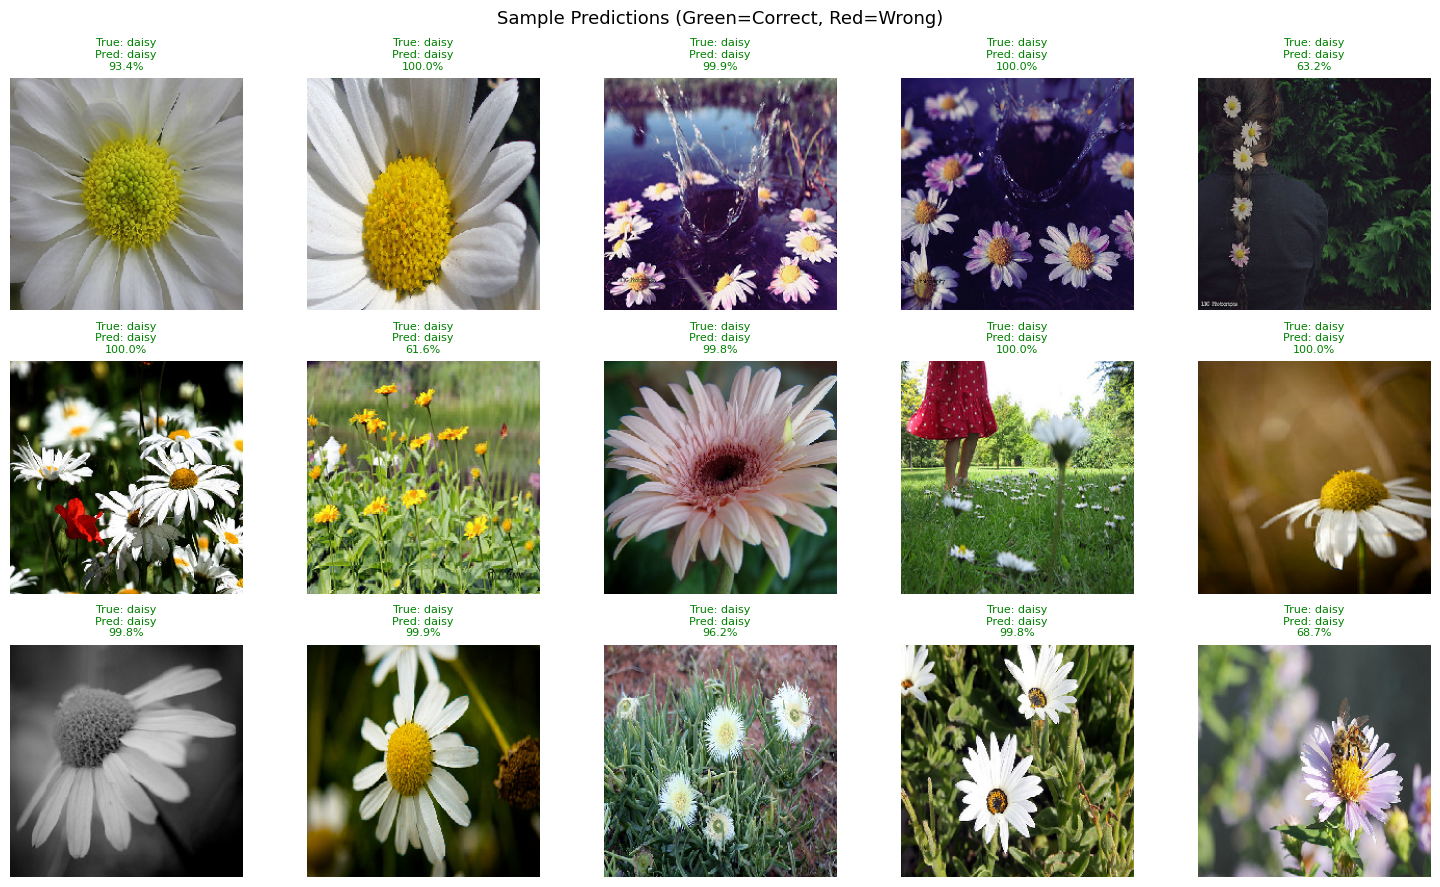

In [ ]:
val_gen.reset()
sample_images, sample_labels = next(val_gen)
predictions = model.predict(sample_images)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].astype('uint8'))
    true_class = class_names[np.argmax(sample_labels[i])]
    pred_class = class_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100
    color = 'green' if true_class == pred_class else 'red'
    ax.set_title(f'True: {true_class}\nPred: {pred_class}\n{confidence:.1f}%',
                 fontsize=8, color=color)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()



In [ ]:
print("Per Class Accuracy:")
print("-" * 40)
for i, class_name in enumerate(class_names):
    class_mask = true_labels == i
    class_acc = np.mean(preds[class_mask] == true_labels[class_mask])
    print(f"{class_name:15} → {class_acc*100:.1f}%")

Per Class Accuracy:
----------------------------------------
daisy           → 96.1%
dandelion       → 94.8%
rose            → 89.7%
sunflower       → 93.8%
tulip           → 96.9%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# Save model
shutil.copy('efficientnetb3_flowers.h5',
            '/content/drive/MyDrive/efficientnetb3_flowers.h5')

# Save dataset
shutil.copytree('/content/flowers',
                '/content/drive/MyDrive/flowers')

print("Everything saved to Drive!")


Mounted at /content/drive
Everything saved to Drive!
